# 预习报告
![预习1](预习1.png)
![预习2](预习2.png)

# 原始数据
![数据1](data1.png)
![数据2](data2.png)

# 实验报告

In [1]:
# 准备
import numpy as np
import pint
ureg=pint.UnitRegistry()
quan=ureg.Quantity
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimSun']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题
import pandas as pd

## 1. 磁阻传感器磁电转换特性测量

In [2]:
磁电转换特性=pd.DataFrame({'线圈电流':list(quan([300,250,200,150,100,50,0,-0,-50,-100,-150,-200,-250,-300],'A')),
                    '磁感应强度':list(quan([6,5,4,3,2,1,0,-0,-1,-2,-3,-4,-5,-6],'gauss')),
                    '输出电压':list(quan([1.500,1.271,1.036,0.788,0.533,0.274,0.008,0.001,-0.267,-0.533,-0.796,-1.049,-1.298,-1.536],'V'))})
磁电转换特性

,线圈电流,磁感应强度,输出电压
0,300 ampere,6 gauss,1.5 volt
1,250 ampere,5 gauss,1.271 volt
2,200 ampere,4 gauss,1.036 volt
3,150 ampere,3 gauss,0.788 volt
4,100 ampere,2 gauss,0.533 volt
5,50 ampere,1 gauss,0.274 volt
6,0 ampere,0 gauss,0.008 volt
7,0 ampere,0 gauss,0.001 volt
8,-50 ampere,-1 gauss,-0.267 volt
9,-100 ampere,-2 gauss,-0.533 volt


*第二个零是电流反向并按下复位键后测量的*

拟合参数: 斜率 a = 0.2573, 截距 b = -0.0049
相关系数 r = 0.9998


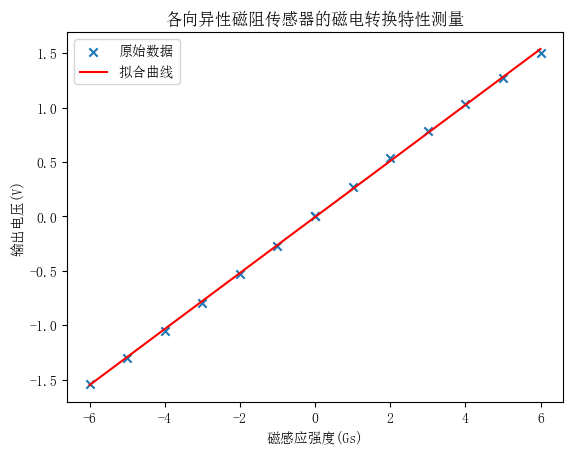

In [3]:
# 定义数据（请替换为你的数据）
x_raw = quan([6,5,4,3,2,1,0,-0,-1,-2,-3,-4,-5,-6],'gauss')
y_raw = quan([1.500,1.271,1.036,0.788,0.533,0.274,0.008,0.001,-0.267,-0.533,-0.796,-1.049,-1.298,-1.536],'V')
x=x_raw.magnitude
y=y_raw.magnitude

# 进行线性拟合
coefficients = np.polyfit(x, y, 1)  # 返回 [斜率, 截距]
a, b = coefficients
print(f"拟合参数: 斜率 a = {a:.4f}, 截距 b = {b:.4f}")

# 生成拟合曲线数据
x_fit = np.linspace(min(x), max(x), 100)
y_fit = np.polyval(coefficients, x_fit)

# 计算相关系数
corr_matrix = np.corrcoef(x, y)
r = corr_matrix[0, 1]
print(f"相关系数 r = {r:.4f}")

# 绘制原始数据和拟合曲线
plt.scatter(x, y, label='原始数据', marker='x')
plt.plot(x_fit, y_fit, 'r-', label='拟合曲线')
plt.xlabel('磁感应强度(Gs)')
plt.ylabel("输出电压(V)")
plt.legend()
plt.title('各向异性磁阻传感器的磁电转换特性测量')
plt.show()

In [4]:
print(f'{a/50/5:.3g}')

0.00103


$a = 0.2573$意味着当被测磁场磁感应强度为$1Gs$时，对应电路面板显示电压为$a V$，由书上说明，放大倍数为$50$，工作电压为$5V$

可知磁阻传感器灵敏度为$1.03mV/V/Gs$

## 2. 磁阻传感器各向异性测量

In [5]:
各向异性=pd.DataFrame({'夹角α':list(quan(np.arange(0,100,10),'degree')),
                  '输出电压':list(quan([1.034,1.020,0.976,0.906,0.802,0.677,0.527,0.353,0.166,-0.026],'V'))})
各向异性

,夹角α,输出电压
0,0 degree,1.034 volt
1,10 degree,1.02 volt
2,20 degree,0.976 volt
3,30 degree,0.906 volt
4,40 degree,0.802 volt
5,50 degree,0.677 volt
6,60 degree,0.527 volt
7,70 degree,0.353 volt
8,80 degree,0.166 volt
9,90 degree,-0.026 volt


$B_0=4Gs$

拟合参数: a = -0.0141, b = 1.0582
决定系数 R² = 0.9995


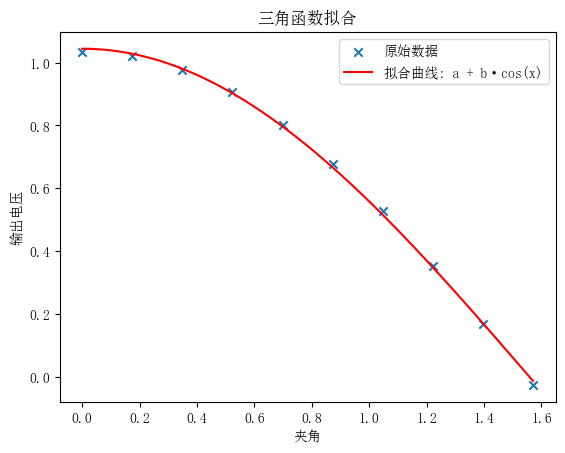

In [6]:
from scipy.optimize import curve_fit

# 定义拟合函数：y = a + b * cos(x)   (x 应为弧度)
def func(x, a, b):
    return a + b * np.cos(x)

x=quan(np.arange(0,100,10),'degree').to('rad').magnitude
y = quan([1.034,1.020,0.976,0.906,0.802,0.677,0.527,0.353,0.166,-0.026],'V').magnitude      

# 初始参数猜测 [a, b]
a0 = np.min(y)
b0 = np.max(y) - np.min(y)
p0 = [a0, b0]

# 进行拟合
popt, pcov = curve_fit(func, x, y, p0=p0)

# 提取参数
a_fit, b_fit = popt
print(f"拟合参数: a = {a_fit:.4f}, b = {b_fit:.4f}")

# 计算决定系数 R²
residuals = y - func(x, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"决定系数 R² = {r_squared:.4f}")

# 生成拟合曲线
x_fit = np.linspace(min(x), max(x), 200)
y_fit = func(x_fit, *popt)

# 绘图
plt.scatter(x, y, label='原始数据',marker='x')
plt.plot(x_fit, y_fit, 'r-', label='拟合曲线: a + b·cos(x)')
plt.xlabel('夹角')
plt.ylabel('输出电压')
plt.legend()
plt.title('三角函数拟合')
plt.show()

考虑到需要将固定大小，方向改变得外磁场投影到磁敏感方向，并根据线性化近似，我们采用三角函数拟合，且效果不错，可以认为曲线是余弦曲线

## 3. 亥姆霍兹线圈轴线上的磁场分布测量

In [7]:
轴线上的磁场=pd.DataFrame({'位置与半径之比X/R':[0.1*i-0.5 for i in range(11)],
                    'B/B0计算值':[0.946,0.975,0.992,0.998,1.000,1,1.000,0.998,0.992,0.975,0.946],
                    '测量值/V':[0.986,1.013,1.026,1.031,1.032,1.032,1.031,1.030,1.023,1.006,0.974]})
轴线上的磁场['测量值/Gs']=轴线上的磁场['测量值/V']/(4/1.032) #比例应该不是0.25
轴线上的磁场

,位置与半径之比X/R,B/B0计算值,测量值/V,测量值/Gs
0,-0.5,0.946,0.986,0.254388
1,-0.4,0.975,1.013,0.261354
2,-0.3,0.992,1.026,0.264708
3,-0.2,0.998,1.031,0.265998
4,-0.1,1.000,1.032,0.266256
5,0.0,1.000,1.032,0.266256
6,0.1,1.000,1.031,0.265998
7,0.2,0.998,1.030,0.265740
8,0.3,0.992,1.023,0.263934
9,0.4,0.975,1.006,0.259548


$B_0=4Gs$

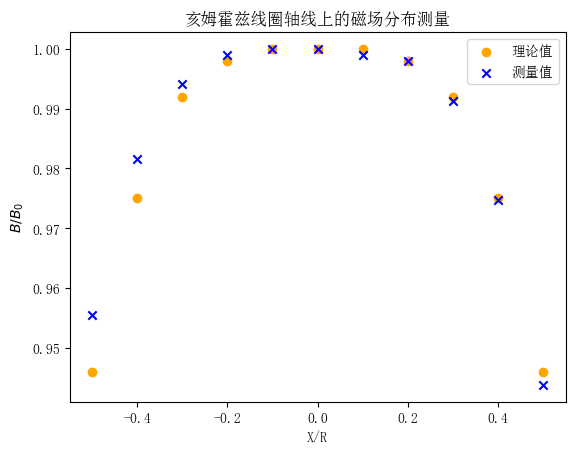

In [8]:
轴线上的磁场['B/B0测量值']=轴线上的磁场['测量值/V']/1.032
plt.scatter(轴线上的磁场['位置与半径之比X/R'], 轴线上的磁场['B/B0计算值'], label='理论值',marker='o',c='orange')
plt.scatter(轴线上的磁场['位置与半径之比X/R'], 轴线上的磁场['B/B0测量值'], label='测量值',marker='x',c='blue')
plt.xlabel('X/R')
plt.ylabel('$B/B_0$')
plt.legend()
plt.title('亥姆霍兹线圈轴线上的磁场分布测量')
plt.show()

在测量范围内中间高，两边低，中间一段变化缓慢，分布均匀

## 4. 亥姆霍兹线圈的空间磁场分布测量

数据

In [9]:
R=ureg('0.14m').to('cm')
t=np.around(np.linspace(0,0.3,7),2)
Y=X=t*R
Vx=quan(np.array([
    [1.034,1.034,1.031,1.030,1.029,1.029,1.025],
    [1.031,1.031,1.031,1.031,1.030,1.028,1.026],
    [1.030,1.030,1.030,1.030,1.029,1.028,1.025],
    [1.030,1.030,1.029,1.030,1.030,1.030,1.028],
    [1.028,1.028,1.029,1.031,1.032,1.033,1.032],
    [1.028,1.028,1.029,1.031,1.034,1.036,1.037],
    [1.026,1.026,1.028,1.031,1.035,np.nan,np.nan]
]))*ureg('V')
B0=ureg('4gauss')
B=B0/Vx[0,0]*Vx

$V_x$表格，行$X$，列$Y$

In [10]:
Vxtable=pd.DataFrame(Vx.magnitude,
                     columns=[str(i)+"R" if i!=0 else "0" for i in t],
                     index=[str(i)+"R" if i!=0 else "0" for i in t])
Vxtable

,0,0.05R,0.1R,0.15R,0.2R,0.25R,0.3R
0,1.034,1.034,1.031,1.030,1.029,1.029,1.025
0.05R,1.031,1.031,1.031,1.031,1.030,1.028,1.026
0.1R,1.030,1.030,1.030,1.030,1.029,1.028,1.025
0.15R,1.030,1.030,1.029,1.030,1.030,1.030,1.028
0.2R,1.028,1.028,1.029,1.031,1.032,1.033,1.032
0.25R,1.028,1.028,1.029,1.031,1.034,1.036,1.037
0.3R,1.026,1.026,1.028,1.031,1.035,NaN,NaN


$B_0=4Gs$

*注：此处两个缺失值是因为测到最后两个点时电压示数突然跳到0.7V，只能停止测量，询问过老师，老师说不用再从头测量了*

$B$表格，行$X$，列$Y$

In [11]:
Vxtable=pd.DataFrame(np.around(B.magnitude,3),
                     columns=[str(i)+"R" if i!=0 else "0" for i in t],
                     index=[str(i)+"R" if i!=0 else "0" for i in t])
Vxtable

,0,0.05R,0.1R,0.15R,0.2R,0.25R,0.3R
0,4.000,4.000,3.988,3.985,3.981,3.981,3.965
0.05R,3.988,3.988,3.988,3.988,3.985,3.977,3.969
0.1R,3.985,3.985,3.985,3.985,3.981,3.977,3.965
0.15R,3.985,3.985,3.981,3.985,3.985,3.985,3.977
0.2R,3.977,3.977,3.981,3.988,3.992,3.996,3.992
0.25R,3.977,3.977,3.981,3.988,4.000,4.008,4.012
0.3R,3.969,3.969,3.977,3.988,4.004,NaN,NaN


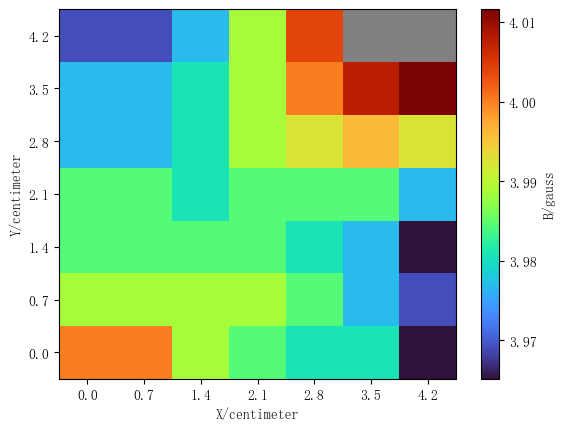

In [12]:
from matplotlib.colors import LinearSegmentedColormap
# 获取当前 colormap，并设置 'bad' 颜色（用于 nan）
cmap = plt.cm.turbo.copy()
cmap.set_bad(color='gray')  # 将所有 nan 显示为灰色
plt.imshow(B.magnitude,origin='lower', cmap=cmap, interpolation='none', aspect='auto')
plt.colorbar(label=f'B/{B.units}')
plt.xticks(ticks=np.arange(len(X)), labels=np.around(X.magnitude,1))
plt.yticks(ticks=np.arange(len(Y)), labels=np.around(Y.magnitude,1))
plt.xlabel(f'X/{X.units}')
plt.ylabel(f'Y/{Y.units}')
plt.show()

---
理论计算

1. 单个圆环电流的空间磁场

对于单个半径为$R$、通电流$I$的圆环，空间任意点$P(ρ, z)$（柱坐标，ρ为径向距离）的磁场有两个分量：

- **轴向分量** $B_z$
- **径向分量** $B_\rho$

公式为（采用国际单位制）：

$$
\begin{aligned}
B_\rho &= \frac{\mu_0 I}{2\pi} \frac{z}{\rho\sqrt{(R+\rho)^2 + z^2}} \left[ -K(k) + \frac{R^2+\rho^2+z^2}{(R-\rho)^2+z^2} E(k) \right] \\
B_z &= \frac{\mu_0 I}{2\pi} \frac{1}{\sqrt{(R+\rho)^2 + z^2}} \left[ K(k) + \frac{R^2-\rho^2-z^2}{(R-\rho)^2+z^2} E(k) \right]
\end{aligned}
$$

其中：
- $K(k)$ 为第一类完全椭圆积分
- $E(k)$ 为第二类完全椭圆积分
- 模数 $k$ 由下式给出：
  $$
  k^2 = \frac{4R\rho}{(R+\rho)^2 + z^2}
  $$

注意：当 $\rho = 0$（轴线上）时，这些公式退化为

$$
B = \frac{\mu_0 N I R^2}{2\left(R^2 + z^2\right)^{3/2}}
$$

---

2. 亥姆霍兹线圈的离轴磁场

亥姆霍兹线圈由两个相同的圆环组成，分别位于 $z = -R/2$ 和 $z = R/2$。空间某点的总磁场就是两个线圈的贡献之和：

$$
\begin{aligned}
B_{\rho}^{\text{total}}(\rho, z) &= B_\rho(\rho, z + R/2) + B_\rho(\rho, z - R/2) \\
B_z^{\text{total}}(\rho, z) &= B_z(\rho, z + R/2) + B_z(\rho, z - R/2)
\end{aligned}
$$

其中 $B_\rho$ 和 $B_z$ 使用上面的单线圈公式计算。

---

3. 无量纲磁场表达式

将两线圈轴线中点处磁场强度 $B_0$ 提出后，亥姆霍兹线圈的空间磁场可表示为仅依赖于归一化坐标 $\tilde{\rho} = \rho / R$ 和 $\tilde{z} = z / R$ 的无量纲形式。这样，任意点的磁场分量即为 $B_0$ 乘以相应的无量纲函数。

定义 $b_\rho = B_\rho / B_0$，$b_z = B_z / B_0$，则：

轴向分量
$$
b_z(\tilde{\rho}, \tilde{z}) = \frac{5^{3/2}}{16\pi} \left[ \frac{1}{\sqrt{(1+\tilde{\rho})^2 + (\tilde{z}+1/2)^2}} \left( K(k_1) + \frac{1-\tilde{\rho}^2-(\tilde{z}+1/2)^2}{(1-\tilde{\rho})^2+(\tilde{z}+1/2)^2} E(k_1) \right) + \frac{1}{\sqrt{(1+\tilde{\rho})^2 + (\tilde{z}-1/2)^2}} \left( K(k_2) + \frac{1-\tilde{\rho}^2-(\tilde{z}-1/2)^2}{(1-\tilde{\rho})^2+(\tilde{z}-1/2)^2} E(k_2) \right) \right]
$$

径向分量
$$
b_\rho(\tilde{\rho}, \tilde{z}) = \frac{5^{3/2}}{16\pi} \left[ \frac{\tilde{z}+1/2}{\tilde{\rho}\sqrt{(1+\tilde{\rho})^2 + (\tilde{z}+1/2)^2}} \left( -K(k_1) + \frac{1+\tilde{\rho}^2+(\tilde{z}+1/2)^2}{(1-\tilde{\rho})^2+(\tilde{z}+1/2)^2} E(k_1) \right) + \frac{\tilde{z}-1/2}{\tilde{\rho}\sqrt{(1+\tilde{\rho})^2 + (\tilde{z}-1/2)^2}} \left( -K(k_2) + \frac{1+\tilde{\rho}^2+(\tilde{z}-1/2)^2}{(1-\tilde{\rho})^2+(\tilde{z}-1/2)^2} E(k_2) \right) \right]
$$

其中 $K(k)$ 和 $E(k)$ 分别为第一类和第二类完全椭圆积分，模数为：
$$
k_1^2 = \frac{4\tilde{\rho}}{(1+\tilde{\rho})^2 + (\tilde{z}+1/2)^2}, \quad k_2^2 = \frac{4\tilde{\rho}}{(1+\tilde{\rho})^2 + (\tilde{z}-1/2)^2}
$$
轴线上的简化
当 $\tilde{\rho}=0$ 时，径向分量为零，轴向分量退化为：
$$
b_z(0, \tilde{z}) = \frac{(5/4)^{3/2}}{2} \left[ \left(1+(\tilde{z}+1/2)^2\right)^{-3/2} + \left(1+(\tilde{z}-1/2)^2\right)^{-3/2} \right]
$$
在中心点 $\tilde{z}=0$ 处，$b_z(0,0)=1$，与定义一致。

---

4. `Python`实现

In [13]:
from scipy.special import ellipk, ellipe

def b_axial(rho_norm, z_norm):
    """
    计算亥姆霍兹线圈轴向无量纲磁场分量 bz = Bz / B0

    参数:
    rho_norm : array_like, 归一化径向坐标 ρ/R
    z_norm   : array_like, 归一化轴向坐标 z/R

    返回:
    bz : ndarray, 无量纲轴向磁场分量
    """
    rho_norm = np.asarray(rho_norm)
    z_norm = np.asarray(z_norm)
    # 确保输入可以广播
    rho_norm, z_norm = np.broadcast_arrays(rho_norm, z_norm)
    shape = rho_norm.shape
    rho_norm = rho_norm.ravel()
    z_norm = z_norm.ravel()
    bz = np.zeros_like(rho_norm, dtype=float)

    # 处理 rho_norm = 0 的情况（轴线上）
    mask_zero = (rho_norm == 0)
    if np.any(mask_zero):
        z0 = z_norm[mask_zero]
        # 轴线公式：bz = (5/4)^(3/2)/2 * [ (1+(z+0.5)^2)^(-3/2) + (1+(z-0.5)^2)^(-3/2) ]
        factor = (5/4)**1.5 / 2.0  # (5/4)^(3/2)/2
        term1 = (1 + (z0 + 0.5)**2) ** (-1.5)
        term2 = (1 + (z0 - 0.5)**2) ** (-1.5)
        bz[mask_zero] = factor * (term1 + term2)

    # 处理 rho_norm > 0 的情况
    mask_nonzero = ~mask_zero
    if np.any(mask_nonzero):
        r = rho_norm[mask_nonzero]
        z = z_norm[mask_nonzero]

        # 两个线圈的位置偏移
        z_plus = z + 0.5   # 对应线圈位于 z = -0.5? 注意：我们的线圈位于 z = -0.5 和 z = +0.5。
        z_minus = z - 0.5  # 因此对于点 z，相对于线圈1的偏移是 z - (-0.5) = z+0.5，相对于线圈2的偏移是 z - 0.5。

        # 辅助函数计算单个线圈贡献
        def single_coil_axial(r, z_off):
            # 输入 r = ρ̃, z_off = z̃ - z_coil (相对距离)
            # 计算 k^2
            k2 = 4 * r / ((1 + r)**2 + z_off**2)
            k2 = np.clip(k2, 0, 1 - 1e-12)  # 避免数值问题
            K = ellipk(k2)
            E = ellipe(k2)
            # 分母公共部分
            denom = np.sqrt((1 + r)**2 + z_off**2)
            # 第二项中的分数
            frac = (1 - r**2 - z_off**2) / ((1 - r)**2 + z_off**2)
            return (1 / denom) * (K + frac * E)

        # 计算两个线圈的贡献并求和
        total = single_coil_axial(r, z_plus) + single_coil_axial(r, z_minus)
        # 乘以常数因子 5^(3/2)/(16π)
        coeff = (5**1.5) / (16 * np.pi)
        bz[mask_nonzero] = coeff * total

    return bz.reshape(shape)


def b_radial(rho_norm, z_norm):
    """
    计算亥姆霍兹线圈径向无量纲磁场分量 br = Brho / B0

    参数:
    rho_norm : array_like, 归一化径向坐标 ρ/R
    z_norm   : array_like, 归一化轴向坐标 z/R

    返回:
    br : ndarray, 无量纲径向磁场分量
    """
    rho_norm = np.asarray(rho_norm)
    z_norm = np.asarray(z_norm)
    rho_norm, z_norm = np.broadcast_arrays(rho_norm, z_norm)
    shape = rho_norm.shape
    rho_norm = rho_norm.ravel()
    z_norm = z_norm.ravel()
    br = np.zeros_like(rho_norm, dtype=float)

    # 处理 rho_norm = 0 的情况：径向分量为0
    mask_zero = (rho_norm == 0)
    br[mask_zero] = 0.0

    # 处理 rho_norm > 0 的情况
    mask_nonzero = ~mask_zero
    if np.any(mask_nonzero):
        r = rho_norm[mask_nonzero]
        z = z_norm[mask_nonzero]

        z_plus = z + 0.5
        z_minus = z - 0.5

        def single_coil_radial(r, z_off):
            k2 = 4 * r / ((1 + r)**2 + z_off**2)
            k2 = np.clip(k2, 0, 1 - 1e-12)
            K = ellipk(k2)
            E = ellipe(k2)
            denom = np.sqrt((1 + r)**2 + z_off**2)
            # 注意公式中分子有 z_off
            # 项： (z_off) / (r * denom) * ( -K + (1 + r^2 + z_off^2)/((1-r)^2 + z_off^2) * E )
            frac = (1 + r**2 + z_off**2) / ((1 - r)**2 + z_off**2)
            return (z_off / (r * denom)) * (-K + frac * E)

        total = single_coil_radial(r, z_plus) + single_coil_radial(r, z_minus)
        coeff = (5**1.5) / (16 * np.pi)
        br[mask_nonzero] = coeff * total

    return br.reshape(shape)

In [14]:
rho_norm = np.linspace(0, 0.3, 11)
z_norm = np.linspace(0, 0.3, 11)
Rho_norm, Z_norm = np.meshgrid(rho_norm, z_norm)

# 计算 bz
bz = b_axial(Rho_norm, Z_norm)

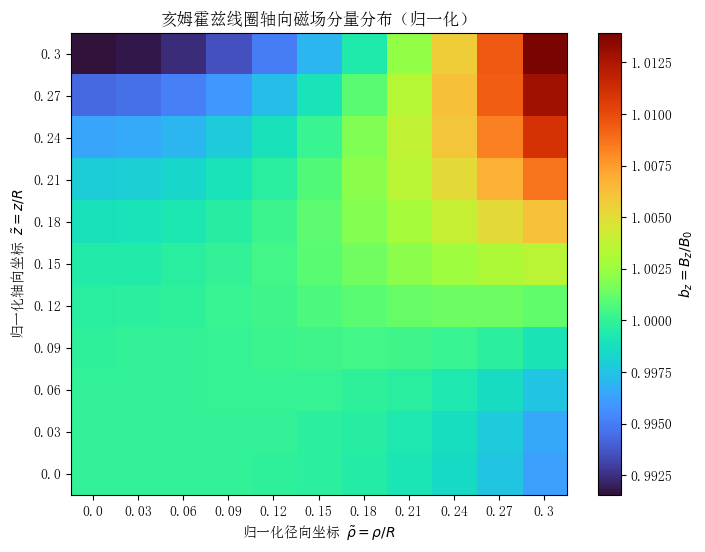

In [15]:
# 绘制热图
plt.figure(figsize=(8, 6))
# plt.imshow(bz, extent=[rho_norm.min(), rho_norm.max(), z_norm.min(), z_norm.max()],
#            origin='lower', aspect='auto', cmap='turbo')
plt.imshow(bz,
           origin='lower', aspect='auto', cmap='turbo')
plt.xticks(ticks=np.arange(len(rho_norm)), labels=np.around(rho_norm,2))
plt.yticks(ticks=np.arange(len(z_norm)), labels=np.around(z_norm,2))
plt.colorbar(label='$b_z = B_z / B_0$')
plt.xlabel('归一化径向坐标 $\\tilde{\\rho} = \\rho / R$')
plt.ylabel('归一化轴向坐标 $\\tilde{z} = z / R$')
plt.title('亥姆霍兹线圈轴向磁场分量分布（归一化）')
plt.show()

比较测量值和理论值（归一化）

In [16]:
ce=(Vx/Vx[0,0]).magnitude
li=b_axial(*np.meshgrid(t,t))

理论值

In [17]:
pd.DataFrame(li,
             columns=[str(i)+"R" if i!=0 else "0" for i in t],
             index=[str(i)+"R" if i!=0 else "0" for i in t])

,0,0.05R,0.1R,0.15R,0.2R,0.25R,0.3R
0,1.000000,0.999997,0.999956,0.999777,0.999283,0.998215,0.996207
0.05R,0.999993,1.000012,1.000037,0.999972,0.999648,0.998815,0.997121
0.1R,0.999886,0.999968,1.000186,1.000455,1.000628,1.000483,0.999708
0.15R,0.999431,0.999612,1.000133,1.000930,1.001888,1.002833,1.003518
0.2R,0.998237,0.998544,0.999454,1.000928,1.002894,1.005246,1.007826
0.25R,0.995802,0.996253,0.997603,0.999844,1.002958,1.006916,1.011672
0.3R,0.991560,0.992158,0.993961,0.996990,1.001287,1.006908,1.013931


测量值

In [18]:
pd.DataFrame(ce,
             columns=[str(i)+"R" if i!=0 else "0" for i in t],
             index=[str(i)+"R" if i!=0 else "0" for i in t])

,0,0.05R,0.1R,0.15R,0.2R,0.25R,0.3R
0,1.000000,1.000000,0.997099,0.996132,0.995164,0.995164,0.991296
0.05R,0.997099,0.997099,0.997099,0.997099,0.996132,0.994197,0.992263
0.1R,0.996132,0.996132,0.996132,0.996132,0.995164,0.994197,0.991296
0.15R,0.996132,0.996132,0.995164,0.996132,0.996132,0.996132,0.994197
0.2R,0.994197,0.994197,0.995164,0.997099,0.998066,0.999033,0.998066
0.25R,0.994197,0.994197,0.995164,0.997099,1.000000,1.001934,1.002901
0.3R,0.992263,0.992263,0.994197,0.997099,1.000967,NaN,NaN


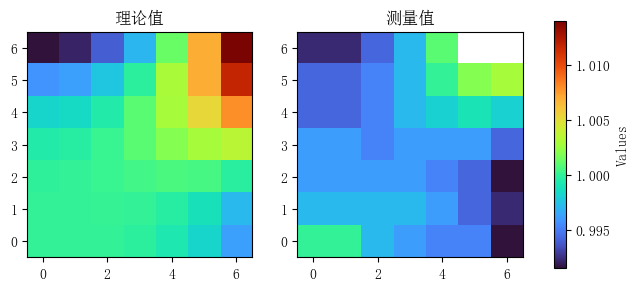

In [19]:
# 统一 vmin/vmax，以便共用颜色条
vmin = min(li.min(), ce.min())
vmax = max(li.max(), ce.max())

# 创建子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# 绘制热图，保存 mappable 对象
im1 = ax1.imshow(li, origin='lower', vmin=vmin, vmax=vmax, cmap='turbo')
im2 = ax2.imshow(ce, origin='lower', vmin=vmin, vmax=vmax, cmap='turbo')

# 添加标题等
ax1.set_title('理论值')
ax2.set_title('测量值')

# 添加共用的颜色条
cbar = fig.colorbar(im1, ax=[ax1, ax2], orientation='vertical', shrink=0.8)
cbar.set_label('Values')

plt.show()

描述：虽然测量值与理论值相比误差较大，但由图可以看出磁场分布为以轴线点为原点，在垂直和沿轴线方向都是递减的，而倾斜方向则是递增的

## 5. 地磁场测量

In [20]:
地磁场1=pd.DataFrame({'磁倾角':[ureg('53 degree')],
                   '磁偏角':[ureg('15.9 degree')],
                   'U1':[ureg('-0.045 V')],
                   'U2':[ureg('-0.243 V')]})
地磁场1['U']=(地磁场1['U1']-地磁场1['U2'])/2
地磁场1['B']=[地磁场1['U'][0]/ureg('0.25 volt/gauss')]
地磁场1

,磁倾角,磁偏角,U1,U2,U,B
0,53 degree,15.9 degree,-0.045 volt,-0.243 volt,0.099 volt,0.396 gauss


经查询北京地区的磁倾角理论值约为 57°，地磁场强度约 0.5—0.6 高斯，水平分量0.35高斯，本实验测得数据偏小

## 误差来源

1. 环境
   - 电磁干扰：实验室中带电设备，含铁设备较多，实验过程中附近同学的亥姆霍兹线圈产生的磁场也产生了影响
2. 仪器
   - 显示精度：通过最大值判断地磁场方向时，受限于数字显示最小分度值，在一定角度内都显示-0.045 V，无法准确判断最大值位置，根据对称性可能可以采用顺时针逆时针分别找到从-0.046变为-0.046的角度，取平均值的方法减小误差；同时导致放大倍数不准确，影响后续测量
   - 电压波动：导致同一次实验同一位置处磁场测量值可能不同
   - 磁阻电桥本身存在零点误差
   - 传感器绕轴角度精度：测磁倾角的刻度分度值为10°，这也是选做实验需要通过三角函数确定磁倾角的原因
   - 自身无法确定地理北极：需通过手机判断地理北极方向再手动调整仪器朝向，误差大
   - 仪器制造时的误差：几何形状可能与亥姆霍兹线圈要求存在偏差
3. 测试人员
   - 位置误差：难以准确移动传感器到期望测量点
   - 估读误差：尤其是数字跳变时，难以判断如何取值
   - 导致仪器意外移动

## 选作

In [21]:
地磁场2=pd.DataFrame({'水平U1':[ureg('-0.073 V')],
                   '水平U2':[ureg('-0.218 V')],
                   '竖直U1':[ureg('-0.072 V')],
                   '竖直U2':[ureg('-0.213 V')]})
地磁场2['U水平']=((地磁场2['水平U1']-地磁场2['水平U2'])/2).round(4)
地磁场2['B水平']=[地磁场2['U水平'][0]/ureg('0.25 volt/gauss').round(4)]
地磁场2['U竖直']=((地磁场2['竖直U1']-地磁场2['竖直U2'])/2).round(4)
地磁场2['B竖直']=[地磁场2['U竖直'][0]/ureg('0.25 volt/gauss').round(4)]
地磁场2['磁倾角']=np.arctan((地磁场2['B竖直']/地磁场2['B水平'])[0]).to('degree').round()
地磁场2['B']=np.sqrt((地磁场2['B水平']**2+地磁场2['B竖直']**2)[0]).round(3)
地磁场2

,水平U1,水平U2,竖直U1,竖直U2,U水平,B水平,U竖直,B竖直,磁倾角,B
0,-0.073 volt,-0.218 volt,-0.072 volt,-0.213 volt,0.0725 volt,0.29 gauss,0.0705 volt,0.282 gauss,44.0 degree,0.405 gauss


## 6. 实验后思考题
1. 推导磁阻元件所组成的惠斯通电桥输出公式：$U=V_b \frac{\Delta R}{R}$

   答：由分压，电桥一臂中点电压为$V_b \frac{R+\Delta R}{2R}$，另一臂中点为$V_b \frac{R-\Delta R}{2R}$
   $$U=V_b \frac{R+\Delta R}{2R}-V_b \frac{R-\Delta R}{2R}=V_b \frac{\Delta R}{R}$$
3. 为什么在测量实验室所处位置的地磁场时，将$U=\frac{U_1-U_2}{2}$作为地磁场磁感应强度的测量值？

   答：因为在没有磁场时电桥的四个电阻也可能不完全相等，导致结果偏移。利用对称测量可以消除电桥偏移的影响。
   $$(\frac{R_1+\Delta R}{2R}-\frac{R_3-\Delta R}{2R})-(\frac{R_1-\Delta R}{2R}-\frac{R_3+\Delta R}{2R})=2\frac{\Delta R}{R}$$